In [1]:
%load_ext autoreload
%autoreload 2

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

from geodesiq import *

# Landau-Zener (diabatic evolution)

In [3]:
def H_fun(z, x):
    return np.array([[z, x], [x, -z]])


alpha = 2
beta = 2
dia_alpha = -2
dia_beta = -2

x = 1
z0 = -10

hamiltonian = Hamiltonian(H_fun)
hamiltonian.set_parameters(x=x)
hamiltonian.set_control(control_name='z', pulse_initial=z0, pulse_final=-z0, initial_state=0, final_state=1,
                        alpha=alpha, beta=beta, dia_alpha=dia_alpha, dia_beta=dia_beta)
hamiltonian.solve_problem(pulse_accuracy=int(1000))

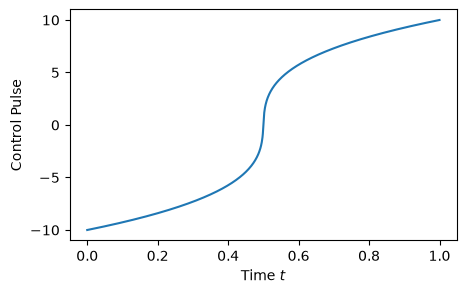

In [5]:
hamiltonian.synthesize_pulse(1).plot_pulse();

In [17]:
def fidelity_vs_time(durations, hamiltonian, alpha, beta):
    # Check that for LZ, the alpha=-2 is already the diabatic one with dia_alpha=2
    hamiltonian.set_control(alpha=alpha, beta=beta)
    hamiltonian.solve_problem(pulse_accuracy=int(1000))

    fidelities = []
    for duration in tqdm(durations):
        dynamics = Dynamics(duration=duration, hamiltonian=hamiltonian)
        fidelities.append(dynamics.state_fidelity())

    return np.array(fidelities)


def fidelity_vs_time_direct(durations, hamiltonian, dia_alpha, dia_beta):
    hamiltonian.set_control(dia_alpha=dia_alpha, dia_beta=dia_beta)
    hamiltonian.solve_problem(pulse_accuracy=int(1000))

    fidelities = []
    for duration in tqdm(durations):
        dynamics = Dynamics(duration=duration, hamiltonian=hamiltonian)
        fidelities.append(dynamics.state_fidelity())

    return np.array(fidelities)

In [23]:
durations = np.linspace(0, 10, 100)

#Adiabatic evolution
hamiltonian.set_control(initial_state=0, final_state=0)
fidelities_geometric = fidelity_vs_time(durations, hamiltonian, alpha=2, beta=2)

  0%|          | 0/100 [00:00<?, ?it/s]

In [24]:
#Diabatic evolution
hamiltonian.set_control(initial_state=0, final_state=1)
fidelities_diabatic = fidelity_vs_time(durations, hamiltonian, alpha=-2, beta=-2)
fidelities_diabatic_direct = fidelity_vs_time_direct(durations, hamiltonian, dia_alpha=-2, dia_beta=-2)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

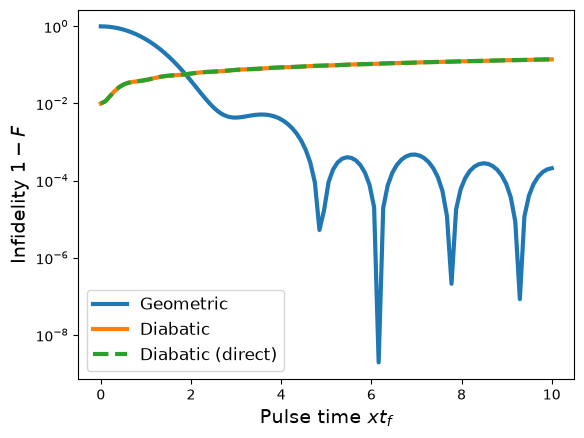

In [25]:
plt.plot(durations, 1 - fidelities_geometric, label='Geometric', lw=3)
plt.plot(durations, 1 - fidelities_diabatic, label='Diabatic', lw=3)
plt.plot(durations, 1 - fidelities_diabatic_direct, label='Diabatic (direct)', lw=3, linestyle='dashed')
plt.yscale('log')
plt.ylabel('Infidelity $1-F$', fontsize=14)
plt.xlabel('Pulse time $x t_f$', fontsize=14)
plt.legend(fontsize=12)
plt.show()